### 군집(clustering)
* 레이블이 없는 데이터에 레이블을 부여하고자 할때 사용
* 비지도 학습으로 유사한 정도에 따라 다수의 객체를 그룹으로 만들때 사용
* 군집을 통해 레이블을 선정하여 지도학습으로 변경
* 군집의 개수 지정하는 방법
    - 감으로(해당 그룹의 개수를 미리 알고 있는 경우)
    - 평가지표로 확인(실루엣 지표 적용( -1 ~ 1사이, 1에 가까울수록 좋다)
    - 그래프 그려서 눈으로 확인

#### k-means
* k-means은 군집화(clustering)에서 가장 일반적으로 사용되는 알고리즘
* 거리기반 군집화다. 특정한 임의의 지점을 선택해 해당 중심에 가장 가까운 포인트들을 선택하는 군집화 기법

#### k-means 파라미터
* n_clusters : 가장 중요한 파라미터로 군집화할 개수를 정의한다.
* init : 초기에 군집 중심점의 좌표를 설정할 방식을 말하며 일반적으로 k-means++방식으로 최초 설정한다
    - k-means++ : 군집하기위한 중심좌표를 찍는 방식이며, 데이터 중 하나를 무작위로 선정후 다음번에는 가장 먼 곳을 중심으로 잡고 진행하는 방식
* max_iter : 최대 반복 횟수이며, 이 횟수 이전에 모든 데이터의 중심점 이동이 없으면 종료한다.

#### 군집화가 완료되면 관련 주요 속성이 있다
* labels_ : 정답을 가지고 있는 변수(군집의 번호)
* cluster_centers_ : 각 군집 중심점 좌표(shape는[군집 개수, 피처 개수]), 이를 이용하면 군집 중심점 좌표가 어디인지 시각화 할 수 있다.

### 고객분류
* 고객들의 정보들을 가지고 있는 데이터 셋이다. 해당 데이터 셋을 이용하여 사용금액에 따른 고객을 분류하고자 한다.
* 분류 대상 : 연간 소득 대비 지출 점수를 통한 분류
* 컬럼
    - CustomerID : 고객 아이디
    - Gender : 성별
    - Age : 나이
    - Annual Income (k$) : 연간소득
    - Spending Score (1-100) : 지출 점수

* 참고 - 필요한 컬럼은 연간 소득과 지출 점수만 있으면 된다.

In [1]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data_set/7.군집/Mall_Customers.csv")
df.head(2)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81


In [3]:
!pip install yellowbrick -qqq

In [8]:
from yellowbrick.cluster import KElbowVisualizer

In [10]:
import warnings
warnings.filterwarnings("ignore")

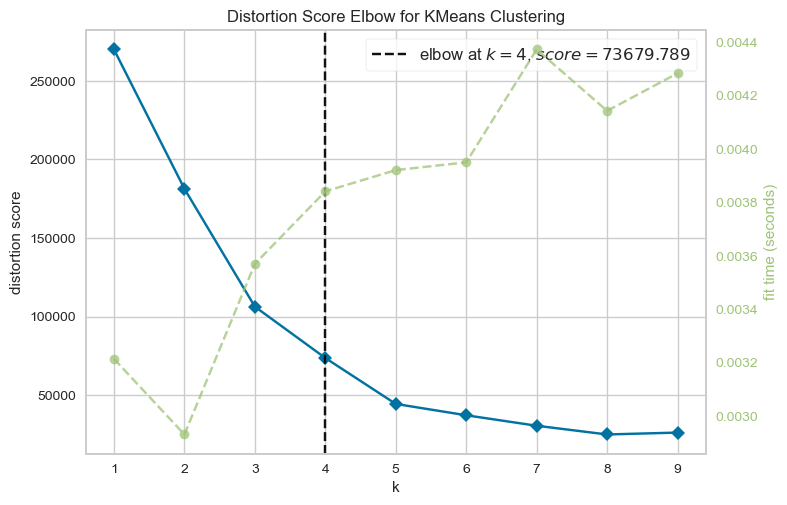

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [14]:
f = ["Annual Income (k$)", "Spending Score (1-100)"]
model = KMeans() # 모델 생성
vis = KElbowVisualizer(model, k=(1, 10)) # k를 1~10까지 바꿔가면서 어떤 k가 좋은 지 찾는 시각화 도구
vis.fit(df[f]) # k가 1~10까지 반복하면서 kmeans 수행
vis.show()

In [15]:
#!pip list

In [16]:
from sklearn.metrics import silhouette_score

In [23]:
km = KMeans(n_clusters=5) #데이터를 5개의 클래스터로 나누겠다
km.fit(df[f])

,n_clusters,5
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [24]:
set(km.labels_) # 중복없이 label 보여준다 set: 중복을 허용하지 않는다

{np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4)}

In [21]:
df[f].head(2)

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81


In [25]:
silhouette_score(df[f], km.labels_) #silhouette: 군집이 잘 되었는지 평가

0.5532176107575425

In [27]:
all_score = []
i = 2 #군집 개수
while i < 10:
    i += 1
    km = KMeans(n_clusters = i)
    km.fit(df[f])
    sil_score = silhouette_score(df[f], km.labels_)
    score_dic = {"cluster num":i, "sil_score":sil_score}
    all_score.append(score_dic)

In [28]:
score_df = pd.DataFrame(all_score)
score_df

,cluster num,sil_score
0,3,0.467614
1,4,0.493795
2,5,0.553932
3,6,0.513005
4,7,0.457236
5,8,0.458771
6,9,0.423643
7,10,0.450566


In [29]:
km = KMeans(n_clusters=5, init="k-means++", max_iter=300) #중심좌표를 아무곳이나 찍어라, 최대 300번 반복
km.fit(df[f])

,n_clusters,5
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [30]:
set(km.labels_)

{np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4)}

In [31]:
df["cluster"] = km.labels_
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster
0,1,Male,19,15,39,2
1,2,Male,21,15,81,4
2,3,Female,20,16,6,2
3,4,Female,23,16,77,4
4,5,Female,31,17,40,2


<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

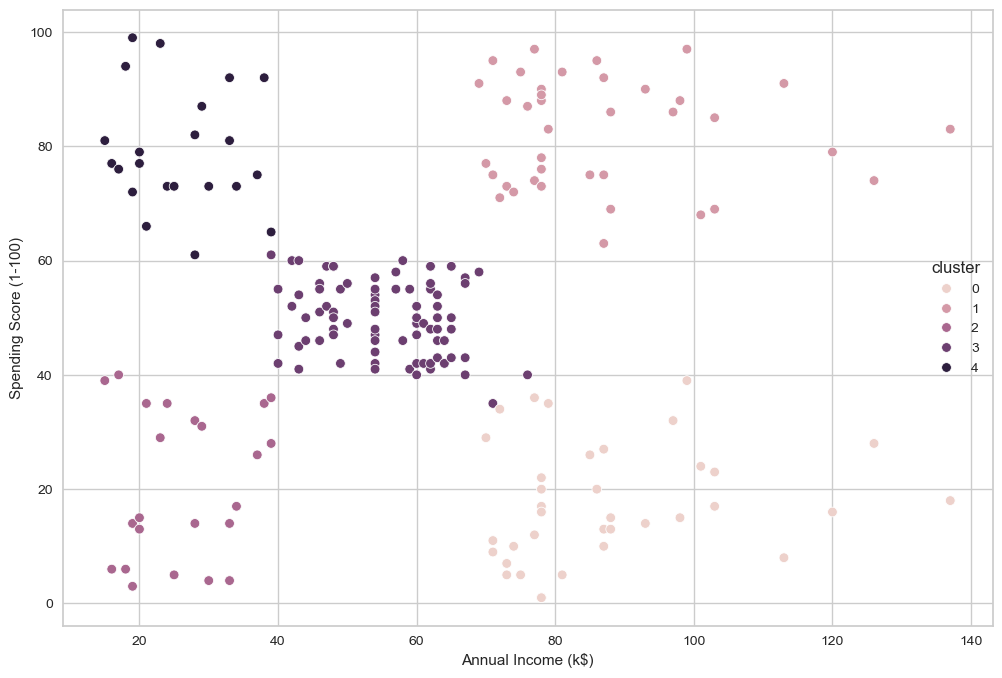

In [35]:
plt.figure(figsize=(12,8))
sns.scatterplot(data=df, x="Annual Income (k$)", y="Spending Score (1-100)", hue="cluster")

In [38]:
cent = km.cluster_centers_ # 각 클러스터의 중심좌표
cent

array([[87.75      , 17.58333333],
       [86.53846154, 82.12820513],
       [26.30434783, 20.91304348],
       [55.0875    , 49.7125    ],
       [25.72727273, 79.36363636]])

In [39]:
cent[:,0] #2차원 배열에서 모든 행의 0번째 열

array([87.75      , 86.53846154, 26.30434783, 55.0875    , 25.72727273])

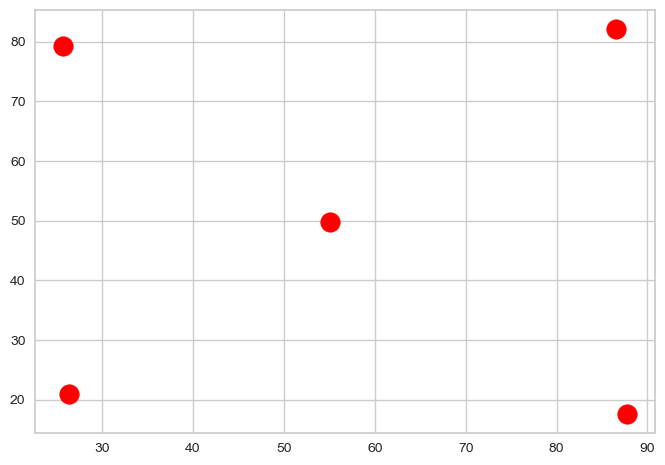

In [40]:
plt.scatter(x=cent[:,0], y=cent[:,1], c="red", s=200) #s: 점 크기

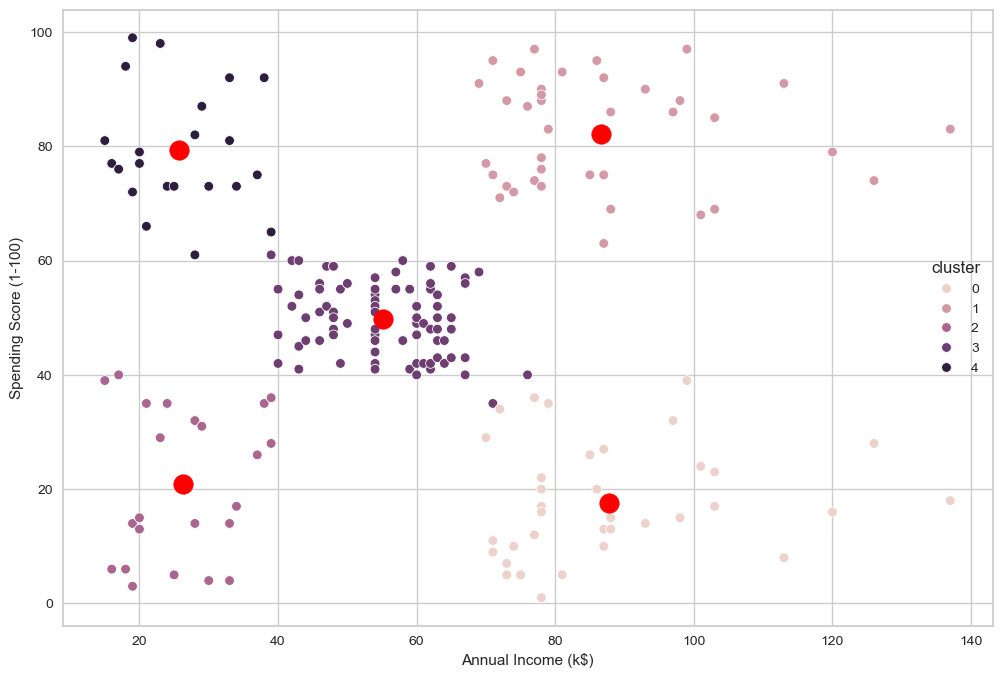

In [41]:
plt.figure(figsize=(12,8))
sns.scatterplot(data=df, x="Annual Income (k$)", y="Spending Score (1-100)", hue="cluster")
plt.scatter(x=cent[:,0], y=cent[:,1], c="red", s=200)

In [ ]:
#레이블 0 - 4
#분류

In [42]:
from sklearn.model_selection import train_test_split

In [45]:
X_train, X_test, y_train, y_test = train_test_split(df[f], df["cluster"], test_size=0.3)

In [46]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

In [47]:
params = {
    "n_estimators":range(5, 100, 10),
    "max_depth":range(4, 11, 2),
    "min_samples_leaf":range(5, 21, 5),
    "min_samples_split":range(4, 21, 4)
}

In [48]:
rfc = RandomForestClassifier()
grid_cv = GridSearchCV(rfc, param_grid = params, cv=3, n_jobs = -1)

In [49]:
grid_cv.fit(X_train, y_train)

,estimator,RandomForestClassifier()
,param_grid,"{'max_depth': range(4, 11, 2), 'min_samples_leaf': range(5, 21, 5), 'min_samples_split': range(4, 21, 4), 'n_estimators': range(5, 100, 10)}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,15


In [50]:
print("최적의 파라미터 : ", grid_cv.best_params_)
print("train : ", grid_cv.score(X_train, y_train))
print("test : ", grid_cv.score(X_test, y_test))

최적의 파라미터 :  {'max_depth': 4, 'min_samples_leaf': 5, 'min_samples_split': 4, 'n_estimators': 15}
train :  1.0
test :  0.95


In [52]:
grid_cv.predict([[50,50]])

array([3], dtype=int32)